In [2]:
import sys
from pathlib import Path

print(123)

# Local run: find project root by looking for scripts/ directory
_here = Path().resolve()
DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')
sys.path.insert(0, DRIVE_ROOT)
sys.path.insert(0, AI_TOOLKIT)

print(f"DRIVE_ROOT: {DRIVE_ROOT}")

INPUT_JSONL = f'{DRIVE_ROOT}/data/filtered_pairs.jsonl'
OUTPUT_JSONL = f'{DRIVE_ROOT}/data/captioned_pairs.jsonl'

123
DRIVE_ROOT: C:\Users\user\Desktop\liya_diplomCC


In [1]:
import sys
from pathlib import Path

# Defensive: re-apply path setup so this cell works even if Cell 1 wasn't run.
_here = Path().resolve()
DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
if DRIVE_ROOT not in sys.path:
    sys.path.insert(0, DRIVE_ROOT)
INPUT_JSONL = globals().get('INPUT_JSONL', f'{DRIVE_ROOT}/data/ w.jsonl')
OUTPUT_JSONL = globals().get('OUTPUT_JSONL', f'{DRIVE_ROOT}/data/captioned_pairs.jsonl')

from scripts.caption_llava import caption_batch

caption_batch(input_jsonl=INPUT_JSONL, output_jsonl=OUTPUT_JSONL)
print("Captioning complete")

Captioning 803 images (0 already done)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

c:\Users\user\Desktop\liya_diplomCC\.venv311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--llava-hf--llava-v1.6-mistral-7b-hf. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

c:\Users\user\Desktop\liya_diplomCC\.venv311\Lib\site-packages\accelerate\utils\modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['image_newline']
  warnings.warn(
Some parameters are on the meta device because they were offloaded to the cpu.
  0%|          | 0/803 [00:00<?, ?it/s]You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
100%|██████████| 803/803 [2:51:42<00:00, 12.83s/it]

Captioning complete


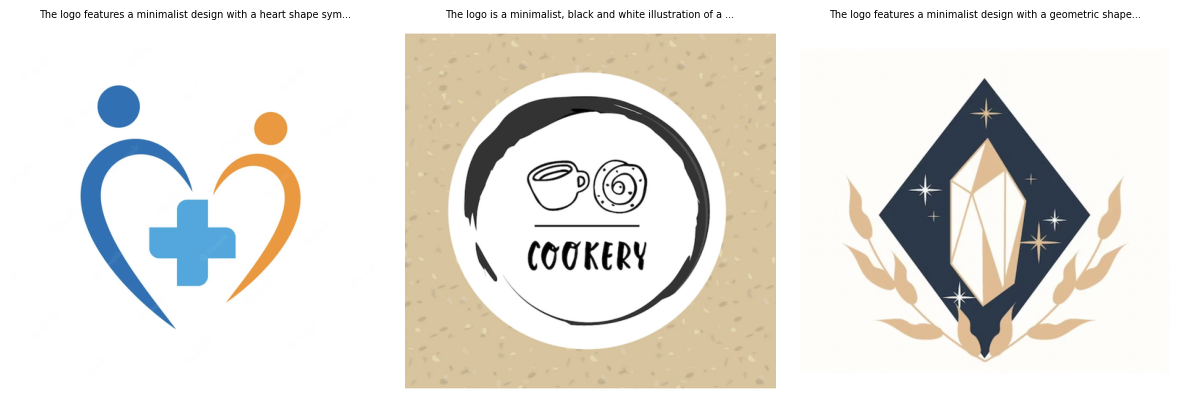

Total captioned: 803


: 

In [ ]:
import json, random
from PIL import Image
import matplotlib.pyplot as plt

with open(OUTPUT_JSONL) as f:
    captioned = [json.loads(l) for l in f]

if not captioned:
    print("No captions found — check Cell 2 output for errors.")
else:
    sample = random.sample(captioned, min(3, len(captioned)))
    fig, axes = plt.subplots(1, len(sample), figsize=(12, 4))
    if len(sample) == 1:
        axes = [axes]
    for ax, item in zip(axes, sample):
        ax.imshow(Image.open(item['png_path']))
        ax.set_title(item['caption'][:60] + "...", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/results/experiments/caption_sample.png', dpi=150)
    plt.show()
    print(f"Total captioned: {len(captioned)}")